Mounted at /content/drive
(5600, 224, 224, 3)
(5600,)
(1600, 224, 224, 3)
(1600,)


Text(0.5, 1.0, '1')

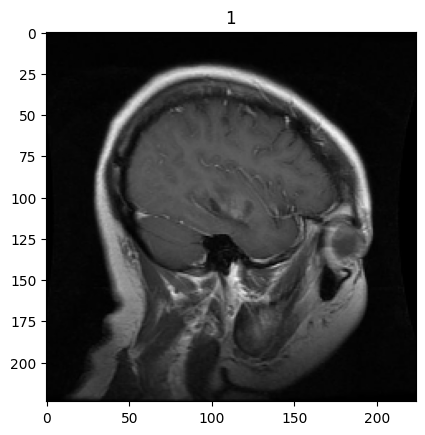

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.applications import InceptionV3
from keras.models import Model, Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.callbacks import  ReduceLROnPlateau
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
drive.mount('/content/drive')

x_train = np.load("/content/drive/MyDrive/MedScan/BrainTumor224TrainX.npy")
y_train = np.load("/content/drive/MyDrive/MedScan/BrainTumor224TrainY.npy")
x_test= np.load("/content/drive/MyDrive/MedScan/BrainTumor224TestX.npy")
y_test = np.load("/content/drive/MyDrive/MedScan/BrainTumor224TestY.npy")

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)
plt.imshow(x_train[0])
plt.title(f"{y_train[0]}")

In [2]:
data_gen = ImageDataGenerator(rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')
data_gen.fit(x_train)
reduce_lr = ReduceLROnPlateau(reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   # metric to watch
    factor=0.2,           # new_lr = lr * factor
    patience=5,           # epochs with no improvement before reducing
    min_lr=1e-6,          # lower bound for learning rate
    verbose=1             # logs the change
))

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 66s 398ms/step - accuracy: 0.7074 - loss: 4.2474 - val_accuracy: 0.8342 - val_loss: 0.4380 - learning_rate: 0.0010
Epoch 2/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - accuracy: 0.8041 - loss: 0.5118 - val_accuracy: 0.8888 - val_loss: 0.3708 - learning_rate: 0.0010
Epoch 3/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - accuracy: 0.8448 - loss: 0.4117 - val_accuracy: 0.9087 - val_loss: 0.2724 - learning_rate: 0.0010
Epoch 4/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - accuracy: 0.8618 - loss: 0.3704 - val_accuracy: 0.9097 - val_loss: 0.2540 - learning_rate: 0.0010
Epoch 5/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - accuracy: 0.8651 - loss: 0.3326 - val_accuracy: 0.9138 - val_loss: 0.2534 - learning_rate: 0.0010
Epoch 6/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 13s 114ms/step - accuracy: 0.8802 - loss: 0.3144 - val_accuracy: 0.9041 - val_loss: 0.2639 - learning_rate: 0.0010
Epoch 7/100
1

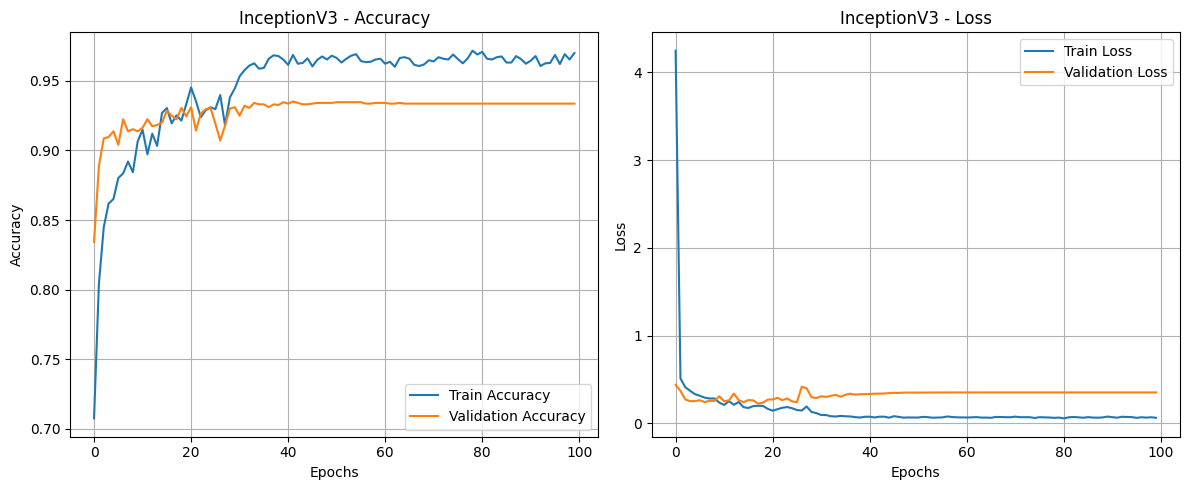

In [3]:
base_model = InceptionV3(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
  layer.trainable = False
x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(len(np.unique(y_train)), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=["accuracy"])
history = model.fit(
    x_train, y_train,
    epochs=100,
    validation_split=0.35,
    callbacks=[reduce_lr]
)

test_loss, test_accuracy = model.evaluate(x_test, y_test)
test_accuracy *= 100
print(f'Test Accuracy: {test_accuracy:.2f}% | Test Loss: {test_loss:.4f}')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('InceptionV3 - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('InceptionV3 - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [4]:
model.save("/content/drive/MyDrive/MedScan/BrainTumorInceptionV3(A89L08).keras")
